# Supervised Machine Learning - Identify Author

In [2]:
!pip install -q spacy


[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import spacy

## The Dataset
Our two datasets are constructed from two related works of 19th century American transcendentalism. These are both public domain.

1. [Essays by Ralph Waldo Emerson by Ralph Waldo Emerson](https://www.google.com/url?q=https%3A%2F%2Fwww.gutenberg.org%2Febooks%2F16643)
2. [Walden, and On The Duty Of Civil Disobedience by Henry David Thoreau](https://www.google.com/url?q=https%3A%2F%2Fwww.gutenberg.org%2Febooks%2F205)

These two authors had different writing styles but shared more than their philosophical interests—they were neighbors in Concord, Massachusetts.

These two works are also similar in length when formatted as plain text.

We will use spaCy to segment each work into sections of roughly 3 to 5 sentences each, then build a datafrom of the text including a label of 'emerson' or 'thoreau', then shuffle and split that into train and test sets for training some machine learning models to classify them by predicting which author they are from and compare the results.

We will also preprocess text to remove stopwords,and perform lemmatization.

In [2]:
emerson_txt_url = "https://www.gutenberg.org/ebooks/16643.txt.utf-8"
thoreau_txt_url = "https://www.gutenberg.org/ebooks/205.txt.utf-8"

In [3]:
import requests
from pathlib import Path

In [4]:
def download_file(url):
  local_filename = Path(url.split('/')[-1])
  result = requests.get(url)
  result.raise_for_status()
  with open(local_filename, "wb") as f:
      f.write(result.content)
  return local_filename

In [5]:
emerson_file = download_file(emerson_txt_url)
thoreau_file = download_file(thoreau_txt_url)

In [6]:
!head -n 50 {emerson_file}

The Project Gutenberg eBook of Essays by Ralph Waldo Emerson
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Essays by Ralph Waldo Emerson

Author: Ralph Waldo Emerson

Editor: Edna Henry Lee Turpin

Release date: September 4, 2005 [eBook #16643]
                Most recently updated: April 29, 2022

Language: English

Credits: Curtis A. Weyant, Sankar Viswanathan and the Online Distributed Proofreading Team


*** START OF THE PROJECT GUTENBERG EBOOK ESSAYS BY RALPH WALDO EMERSON ***




                                ESSAYS

                                  BY

                     

In [7]:
!head -n 50 {thoreau_file}

The Project Gutenberg eBook of Walden, and On The Duty Of Civil Disobedience
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: Walden, and On The Duty Of Civil Disobedience

Author: Henry David Thoreau

Release date: January 1, 1995 [eBook #205]
                Most recently updated: September 19, 2024

Language: English

Credits: Judith Boss, and David Widger


*** START OF THE PROJECT GUTENBERG EBOOK WALDEN, AND ON THE DUTY OF CIVIL DISOBEDIENCE ***
WALDEN




and



ON THE DUTY OF CIVIL DISOBEDIENCE



by Henry David Thoreau


cover


Contents


 WALDEN

 Economy
 Where I Lived, and W

In [8]:
# Let's strip the frontmatter lines off the start of each file.
# remove each line preceding one that contains "START OF THE PROJECT GUTENBERG EBOOK "
!grep -n "START OF THE PROJECT GUTENBERG EBOOK" {emerson_file}
!grep -n "START OF THE PROJECT GUTENBERG EBOOK" {thoreau_file}

25:*** START OF THE PROJECT GUTENBERG EBOOK ESSAYS BY RALPH WALDO EMERSON ***
23:*** START OF THE PROJECT GUTENBERG EBOOK WALDEN, AND ON THE DUTY OF CIVIL DISOBEDIENCE ***


In [9]:
def trim_frontmatter(filename):
  with open(filename) as f:
    lines = f.readlines()

  n_trim_lines = 0
  for i, line in enumerate(lines):
    if "START OF THE PROJECT GUTENBERG EBOOK" in line:
      n_trim_lines = i + 1
      break

  trimmed_lines = lines[n_trim_lines:]
  trimmed_content = '\n'.join(trimmed_lines)
  new_filename = f"trimmed_{filename}"
  with open(new_filename, "w") as f:
    f.write(trimmed_content)
  return new_filename

In [10]:
trimmed_emerson_file = trim_frontmatter(emerson_file)
trimmed_thoreau_file = trim_frontmatter(thoreau_file)

In [11]:
!head {trimmed_emerson_file}
!head {trimmed_thoreau_file}









                                ESSAYS

WALDEN











In [13]:
from collections import deque
from random import randint
import itertools


In [15]:
# First time you will need to download the spacy model.
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.8 MB/s eta 0:00:0000:010:01

[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [16]:
nlp = spacy.load("en_core_web_sm")

In [17]:
def segment_doc(filename):
  with open(filename) as f:
    text = f.read()
  doc = nlp(text)
  assert doc.has_annotation("SENT_START")

  sent_dq = deque()
  #it = doc.sents.__iter__()
  n = randint(3, 5)

  for sent in doc.sents:
    sent_dq.append(sent)
    if len(sent_dq) > n:
      sent_dq.popleft()
      snippet = " ".join(sent.text for sent in sent_dq)
      yield snippet
      n = randint(3, 5)
      sent_dq.clear()

In [18]:
import pandas as pd

In [19]:
def dataframe_from_file(file_path):
  segments = segment_doc(file_path)
  return pd.DataFrame(segments, columns=["text"])

In [21]:
emerson_df = dataframe_from_file(trimmed_emerson_file)
emerson_df.to_csv("emerson.csv")
emerson_df.info()
emerson_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1070 non-null   object
dtypes: object(1)
memory usage: 8.5+ KB


,text
0,The editors of the several volumes will be\n\n...
1,"As a school-boy he was quiet and retiring, rea..."
2,"He was always serene and\n\nthoughtful, impres..."
3,His talent seems to have been in\n\ngiving new...
4,It is\n\ncharacteristic of his deep humanity a...


In [22]:
thoreau_df = dataframe_from_file(trimmed_thoreau_file)
thoreau_df.to_csv("thoreau.csv")
thoreau_df.info()
thoreau_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842 entries, 0 to 841
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    842 non-null    object
dtypes: object(1)
memory usage: 6.7+ KB


,text
0,I lived there two\n\nyears and two months. At ...
1,I will therefore ask those of my readers who f...
2,Perhaps these pages are more\n\nparticularly a...
3,What\n\nI have heard of Brahmins sitting expos...
4,"Why should they eat their sixty acres, when ma..."


In [26]:
# combine and shuffle the datasets, using a consistent random seed.
from sklearn.utils import shuffle

d1 = emerson_df.copy()
d1["label"] = "emerson"

d2 = thoreau_df.copy()
d2["label"] = "thoreau"

combined_df = pd.concat([d1, d2])
combined_df = shuffle(combined_df, random_state=7919)
combined_df.to_csv("combined.csv")

## Now we have our dataset in combined.csv

You can start from here on subsequent runs rather than downloading the data and preprocessing it again.

In [27]:
combined_df = pd.read_csv('combined.csv')
combined_df.info()
combined_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1912 entries, 0 to 1911
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1912 non-null   int64 
 1   text        1912 non-null   object
 2   label       1912 non-null   object
dtypes: int64(1), object(2)
memory usage: 44.9+ KB


,Unnamed: 0,text,label
0,148,It is best to avoid the beginnings of\n\nevil....,thoreau
1,638,Entire self-possession may make a battle very ...,emerson
2,680,I\n\nam particularly attracted by the arching ...,thoreau
3,409,"What fact more conspicuous in modern history, ...",emerson
4,33,There are some\n\nwho complain most energetica...,thoreau


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# you can start here if csv files were already created.
from sklearn.feature_extraction.text import TfidfVectorizer

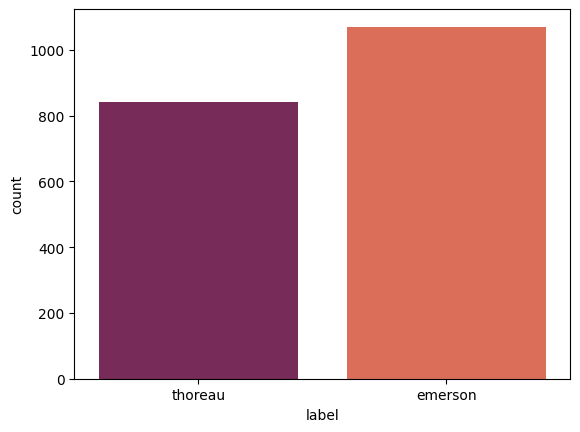

In [33]:
sns.countplot(data=combined_df, x='label', hue='label', palette="rocket")
plt.show()

In [311]:
!pip install -q wordcloud

In [34]:
from spacy.lang.en import STOP_WORDS
my_stopwords = STOP_WORDS

', '.join(my_stopwords)

"everyone, with, front, two, are, am, being, 'll, anyway, wherever, into, hereby, eight, nobody, who, n’t, whither, have, put, 've, towards, just, beforehand, under, 're, becomes, third, thru, might, ‘ve, someone, throughout, neither, when, how, above, hereupon, via, my, eleven, empty, except, him, somewhere, whenever, it, has, first, done, latterly, never, about, if, the, again, due, take, fifteen, already, say, were, ca, part, out, top, could, mine, get, become, almost, on, thence, ’d, up, from, ’m, been, you, give, down, at, nothing, over, he, along, since, against, hence, whose, thereafter, re, must, such, yet, can, most, ‘d, twelve, regarding, sixty, here, therein, hundred, between, me, because, however, ‘m, hers, himself, yourselves, below, do, ’re, off, forty, would, then, had, but, hereafter, other, five, its, same, us, fifty, quite, whence, herself, nevertheless, less, too, whereas, some, 'm, really, various, upon, whole, anywhere, within, six, seemed, where, she, did, all, an

In [35]:
# Show wordcloud from each dataset.
from wordcloud import WordCloud


def plot_word_cloud(text_sections, title):
  cloud = WordCloud(background_color='black', stopwords=my_stopwords).generate(str(text_sections))
  fig = plt.figure(figsize=(12,8), facecolor='white')
  plt.imshow(cloud, interpolation="bilinear")
  plt.axis('off')
  plt.title(title, fontsize=48)
  plt.tight_layout(pad=0)
  plt.show()




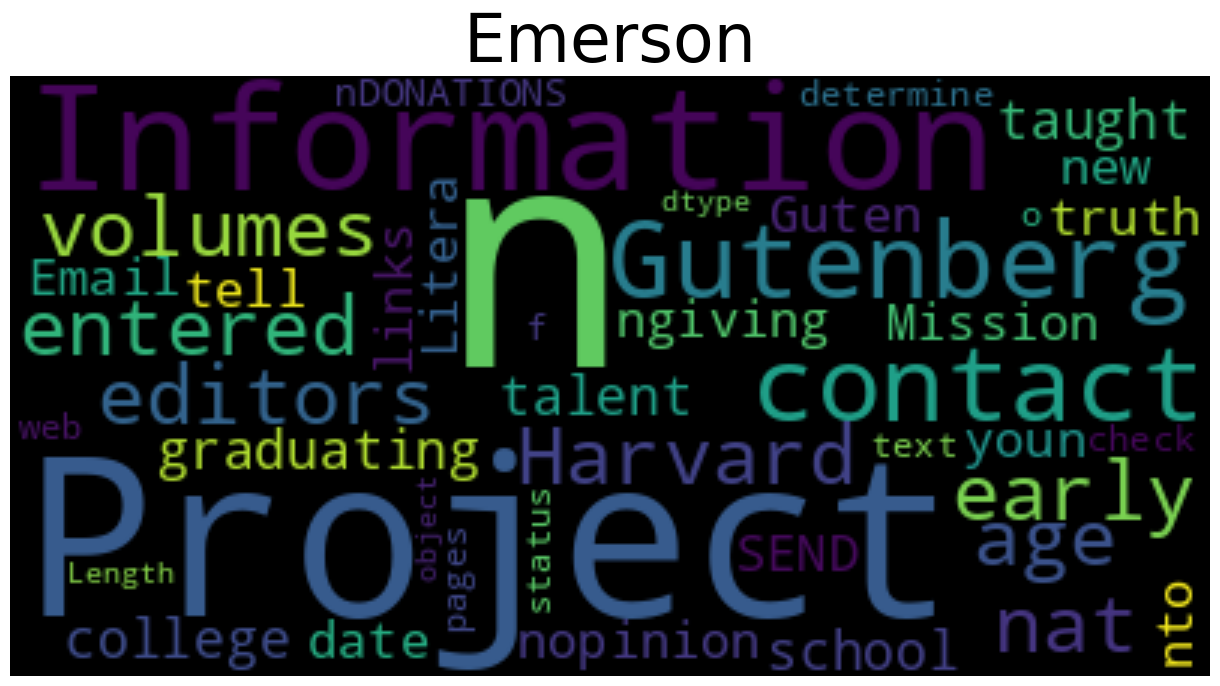

In [314]:
plot_word_cloud(emerson_df["text"], "Emerson")

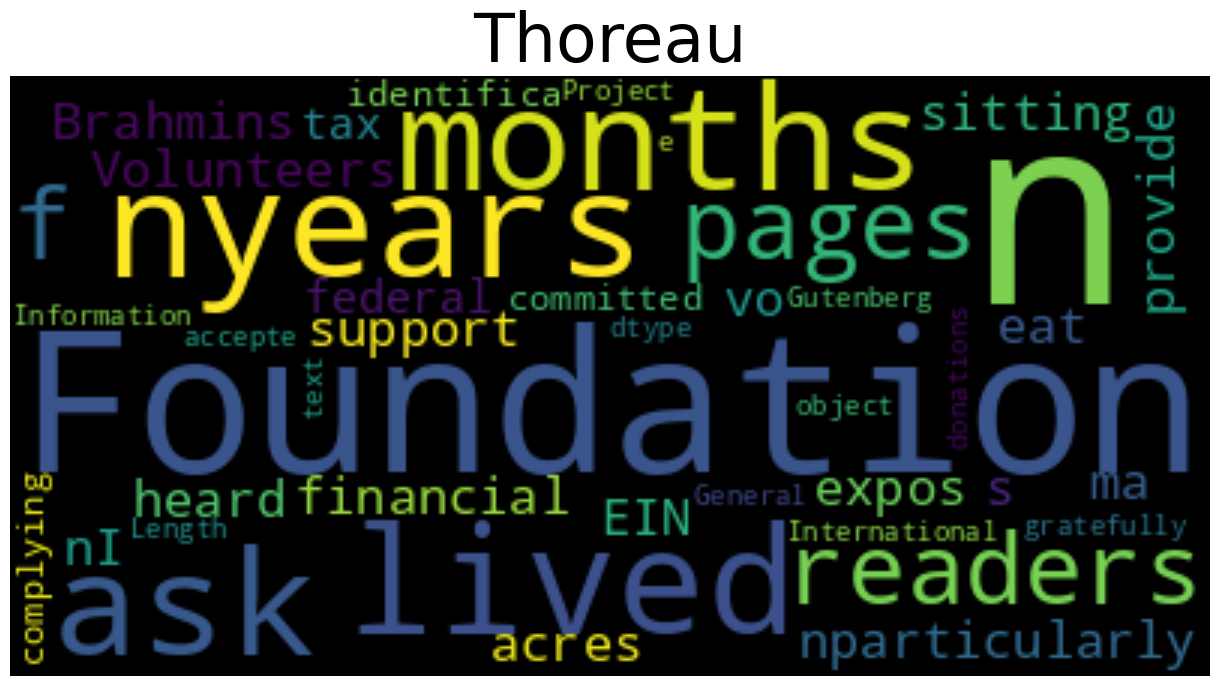

In [36]:
plot_word_cloud(thoreau_df["text"], "Thoreau")

In [37]:
# Preprocess text to remove stopwords, and perform lemmatization.

final_text = []
for index,entry in enumerate(combined_df['text']):
  doc = nlp(entry.lower())
  final_words = []
  for word in doc:
    if not word.is_stop and not word.is_punct:
      final_words.append(word.lemma_)
  final_text.append(' '.join(final_words))

In [38]:
combined_df['final_text'] = final_text
combined_df.head()

,Unnamed: 0,text,label,final_text
0,148,It is best to avoid the beginnings of\n\nevil....,thoreau,good avoid beginning \n\n evil \n\n\n\n long ...
1,638,Entire self-possession may make a battle very ...,emerson,entire self possession battle little \n\n dang...
2,680,I\n\nam particularly attracted by the arching ...,thoreau,\n\n particularly attract arching sheaf like \...
3,409,"What fact more conspicuous in modern history, ...",emerson,fact conspicuous modern history creation \n\n ...
4,33,There are some\n\nwho complain most energetica...,thoreau,\n\n complain energetically inconsolably \n\n ...


In [40]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(combined_df["final_text"])
y = combined_df["label"]

In [41]:
# Split our data into train and test sets.
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4909)
print(f"x_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}")
print(f"y_test: {y_test.shape}")

x_train: (1529, 11839)
y_train: (1529,)
x_test: (383, 11839)
y_test: (383,)


In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
# -2 for n_jobs is all but one CPU available.
lr_model = LogisticRegression(solver='saga', random_state=8102, n_jobs=-2)

_ = lr_model.fit(x_train, y_train)

In [45]:
# Generate predictions on test data.
y_pred = lr_model.predict(x_test)

In [46]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from IPython.display import Markdown, display

def show_metrics(y_test, y_pred, model_name):
  display(Markdown(f"# {model_name}"))

  print(classification_report(y_test,y_pred))
  print("Test accuracy:", accuracy_score(y_test,y_pred))
  cm = confusion_matrix(y_test, y_pred)

  labels = ["emerson", "thoreau"]
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
  plt.title('Confusion Matrix')
  plt.ylabel('Actual')
  plt.xlabel('Predicted')
  plt.show()

# Logistic Regression

              precision    recall  f1-score   support

     emerson       0.88      0.95      0.91       206
     thoreau       0.94      0.84      0.89       177

    accuracy                           0.90       383
   macro avg       0.91      0.90      0.90       383
weighted avg       0.90      0.90      0.90       383

Test accuracy: 0.9007832898172323


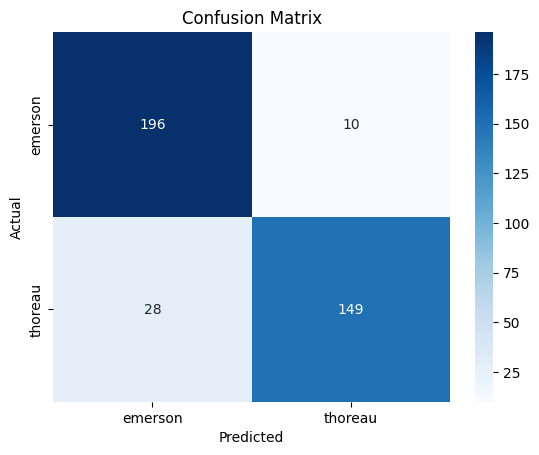

In [47]:
show_metrics(y_test, y_pred, "Logistic Regression")

In [48]:
# Let's compare that to random forests.
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
_ = rf.fit(x_train,y_train)

In [49]:
y_pred_rf = rf.predict(x_test)

# Random Forest

              precision    recall  f1-score   support

     emerson       0.82      0.93      0.87       206
     thoreau       0.91      0.76      0.82       177

    accuracy                           0.85       383
   macro avg       0.86      0.84      0.85       383
weighted avg       0.86      0.85      0.85       383

Test accuracy: 0.8511749347258486


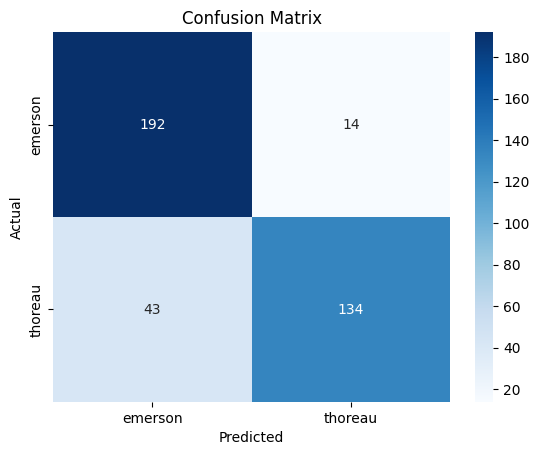

In [50]:
show_metrics(y_test, y_pred_rf, "Random Forest")

In [52]:
# And now to SVM
from sklearn import svm

In [53]:
# create the SVM classifier
clf = svm.SVC(kernel='rbf')

clf.fit(x_train,y_train)
clf

SVC()

In [54]:
y_pred_svm = clf.predict(x_test)

# SVM

              precision    recall  f1-score   support

     emerson       0.88      0.93      0.91       206
     thoreau       0.92      0.86      0.89       177

    accuracy                           0.90       383
   macro avg       0.90      0.90      0.90       383
weighted avg       0.90      0.90      0.90       383

Test accuracy: 0.8981723237597912


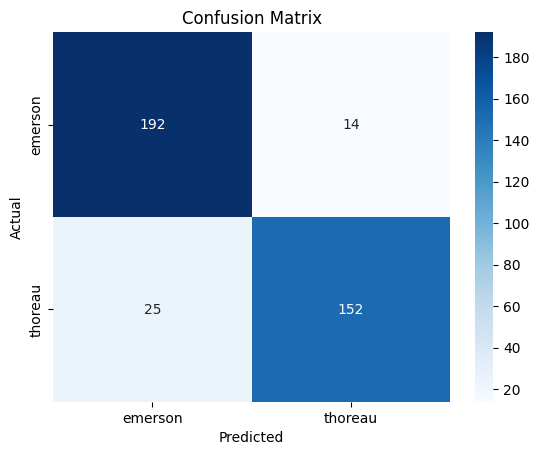

In [55]:
show_metrics(y_test, y_pred_svm, "SVM")

In [332]:
!pip install -q transformers

In [57]:
import torch

In [334]:
from transformers import AutoTokenizer, AutoModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device}")

cuda


In [335]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased", return_token_type_ids = False, padding="max_length", truncation=True)

model = AutoModel.from_pretrained("distilbert-base-uncased").to(device)


In [336]:
x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(combined_df["text"], combined_df["label"], test_size=0.2, random_state=4909)
print(f"x_train_s: {x_train_s.shape}")
print(f"y_train_s: {y_train_s.shape}")
print(f"x_test_s: {x_test_s.shape}")
print(f"y_test_s: {y_test_s.shape}")


x_train_s: (1543,)
y_train_s: (1543,)
x_test_s: (386,)
y_test_s: (386,)


In [337]:
x_train_tok = tokenizer(x_train_s.tolist(), padding=True, truncation=True, return_tensors="pt")
y_train_tok = y_train_s.tolist()

x_test_tok = tokenizer(x_test_s.tolist(), padding=True, truncation=True, return_tensors="pt")
y_test_tok = y_test_s.tolist()


In [338]:
x_train_tok[0:2]

[Encoding(num_tokens=471, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing]),
 Encoding(num_tokens=471, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])]

In [339]:

print(x_train_tok.keys())


#move onto device (GPU)
x_train_tok = {k:torch.tensor(v).to(device) for k,v in x_train_tok.items()}
x_test_tok = {k:torch.tensor(v).to(device) for k,v in x_test_tok.items()}

dict_keys(['input_ids', 'attention_mask'])


<ipython-input-339-cbedc1b8b59f>:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train_tok = {k:torch.tensor(v).to(device) for k,v in x_train_tok.items()}
<ipython-input-339-cbedc1b8b59f>:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test_tok = {k:torch.tensor(v).to(device) for k,v in x_test_tok.items()}


In [340]:
with torch.no_grad():
  hidden_train = model(**x_train_tok)
  hidden_test = model(**x_test_tok)

# Get the [CLS] hidden states
cls_train = hidden_train.last_hidden_state[:,0,:]
cls_test = hidden_test.last_hidden_state[:,0,:]

In [341]:
x_train_db = cls_train.to("cpu")
# y_train_tok

x_test_db = cls_test.to("cpu")
# y_test_tok


In [342]:
lr_model2 = LogisticRegression(C=1, solver='saga', random_state=8102, n_jobs=-2, max_iter=10_000)

lr_model2.fit(x_train_db,y_train_tok)

# This does not converge, with the settings used vor TF-DF
# ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
# So we adjusting max_iter and experimented with C (regulation strength).

y_pred = lr_model2.predict(x_test_db)


# Logistic Regression on DistilBERT hidden states

              precision    recall  f1-score   support

     emerson       0.95      0.91      0.93       222
     thoreau       0.89      0.93      0.91       164

    accuracy                           0.92       386
   macro avg       0.92      0.92      0.92       386
weighted avg       0.92      0.92      0.92       386

Test accuracy: 0.9222797927461139


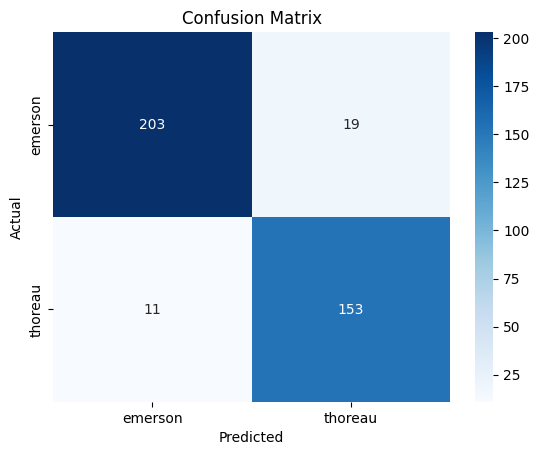

In [343]:
show_metrics(y_test_tok, y_pred, "Logistic Regression on DistilBERT hidden states")

In [344]:
rf = RandomForestClassifier()
rf.fit(x_train_db,y_train_tok)

rf.score(x_test_db,y_test_tok)

y_pred_rf = rf.predict(x_test_db)

# Random Forest on DistilBERT hidden states

              precision    recall  f1-score   support

     emerson       0.88      0.92      0.90       222
     thoreau       0.89      0.82      0.85       164

    accuracy                           0.88       386
   macro avg       0.88      0.87      0.88       386
weighted avg       0.88      0.88      0.88       386

Test accuracy: 0.8808290155440415


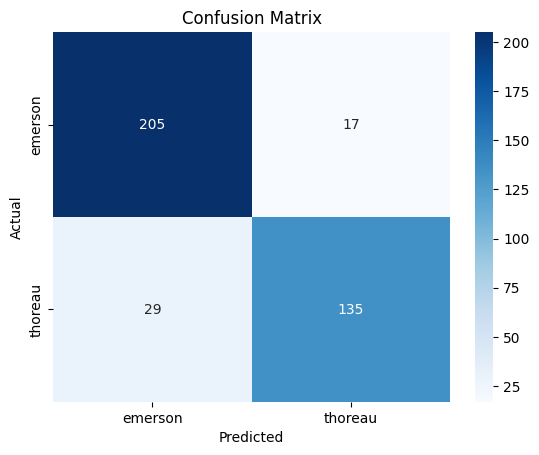

In [345]:
show_metrics(y_test_tok, y_pred_rf, "Random Forest on DistilBERT hidden states")

In [346]:
from sklearn import svm

In [347]:
# create the SVM classifier
clf = svm.SVC(kernel='rbf')

clf.fit(x_train_db,y_train_tok)

y_pred_svm = clf.predict(x_test_db)

# SVM on DistilBERT hidden states

              precision    recall  f1-score   support

     emerson       0.92      0.93      0.93       222
     thoreau       0.90      0.90      0.90       164

    accuracy                           0.91       386
   macro avg       0.91      0.91      0.91       386
weighted avg       0.91      0.91      0.91       386

Test accuracy: 0.9145077720207254


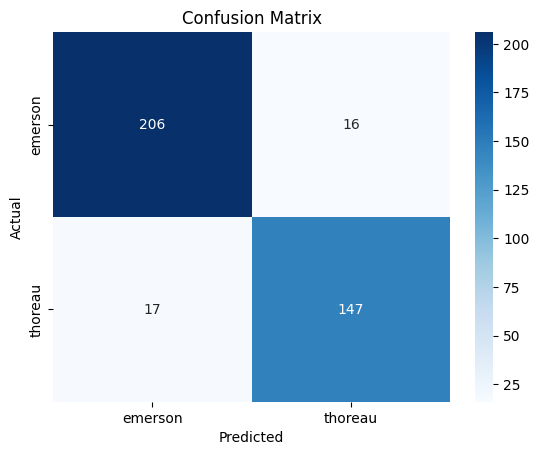

In [348]:
show_metrics(y_test_tok, y_pred_svm, "SVM on DistilBERT hidden states")

In [349]:
from transformers import DistilBertForSequenceClassification

# Define the model with random weights, suitable for binary classification (2 classes)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
# we already have the appropriate tokenizer from before.



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [350]:
# create our optimizer
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)

In [351]:
!pip install -q datasets

In [352]:
from sklearn import preprocessing

# Create a copy of our dataframe
trans_df = combined_df.copy()

# drop the preprocessed text column which we aren't using.
trans_df.drop("final_text", axis=1, inplace=True)

# transform our labels into numeric values.
le = preprocessing.LabelEncoder()
my_labels = trans_df["label"].tolist()
le.fit(my_labels)

my_cat_labels = le.classes_
trans_df["label"] = le.transform(trans_df["label"])

print(f"{my_cat_labels=}")

trans_df.info()
trans_df.describe()
trans_df.head()


my_cat_labels=array(['emerson', 'thoreau'], dtype='<U7')
<class 'pandas.core.frame.DataFrame'>
Index: 1929 entries, 562 to 77
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1929 non-null   object
 1   label   1929 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 45.2+ KB


,text,label
562,They are not yet desired in\n\nthat way. We ha...,0
466,"No wonder, then, that he did not oftener stay ...",1
72,I launch eagerly into this resounding tumult.\...,0
338,"At another time, hearing Plato’s definition of...",1
922,"In Greek mythology, the leader of the satyrs.\...",0


In [353]:
from datasets import Dataset
from transformers import AutoTokenizer

# for simplicity, we are just splitting the dataset again.
train_df, test_df = train_test_split(trans_df, test_size=0.2, random_state=4909)



train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

def tokenize_data(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_train = train_dataset.map(tokenize_data, batched=True)
tokenized_test = test_dataset.map(tokenize_data, batched=True)

Map:   0%|          | 0/1543 [00:00<?, ? examples/s]

Map:   0%|          | 0/386 [00:00<?, ? examples/s]

In [354]:
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    logging_strategy="epoch"
)

# Define Trainer object for training the model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-354-c2f16bbd5fc2>:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.339100,0.319054
2,0.211200,0.316516
3,0.167900,0.308412
4,0.109900,0.270120
5,0.077200,0.295082


TrainOutput(global_step=965, training_loss=0.1810590852727544, metrics={'train_runtime': 51.1636, 'train_samples_per_second': 150.791, 'train_steps_per_second': 18.861, 'total_flos': 446973462858024.0, 'train_loss': 0.1810590852727544, 'epoch': 5.0})

In [355]:
# Save the model.
trainer.save_model('model')

In [356]:
# This is how you can load the model.

# from transformers import AutoModelForSequenceClassification
# model = AutoModelForSequenceClassification.from_pretrained("./model")

In [357]:
def predictor(text):
  #inputs = tokenizer(text, return_tensors="pt")
  inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
  inputs = {k:torch.tensor(v).to(device) for k,v in inputs.items()}

  with torch.no_grad():
      logits = model(**inputs).logits
  predictions = torch.argmax(logits, dim=-1)
  return predictions


In [358]:
x_test_trans = test_dataset["text"]
y_test_trans = test_dataset["label"]

# sanity test a few inference inputs.
for txt, lbl in zip(x_test_trans[:5], y_test_trans[:5]):
  pred = predictor( txt)
  print(f"{my_cat_labels[lbl]}: pred={my_cat_labels[pred]}, {txt=}")

thoreau: pred=thoreau, txt='I sometimes found the name of his native parish handsomely\n\nwritten in the snow by the highway, with the proper French accent, and\n\nknew that he had passed. I asked him if he ever wished to write his\n\nthoughts. He said that he had read and written letters for those who\n\ncould not, but he never tried to write thoughts,—no, he could not, he\n\ncould not tell what to put first, it would kill him, and then there was\n\nspelling to be attended to at the same time!\n\n\n\n I heard that a distinguished wise man and reformer asked him if he did\n\nnot want the world to be changed; but he answered with a chuckle of\n\nsurprise in his Canadian accent, not knowing that the question had ever\n\nbeen entertained before, “No, I like it well enough.”'
thoreau: pred=thoreau, txt='We belong to\n\nthe community. It is not the tailor alone who is the ninth part of a\n\nman; it is as much the preacher, and the merchant, and the farmer.\n\n Where is this division of labo

<ipython-input-357-4d682ed5759f>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = {k:torch.tensor(v).to(device) for k,v in inputs.items()}


In [359]:
y_pred_trans = [predictor(txt) for txt in x_test_trans]

for txt, lbl, pred in zip(x_test_trans[:5], y_test_trans[:5], y_pred_trans[:5]):
  print(f"{my_cat_labels[lbl]}: pred={my_cat_labels[pred]}, {txt=}")


<ipython-input-357-4d682ed5759f>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = {k:torch.tensor(v).to(device) for k,v in inputs.items()}


thoreau: pred=thoreau, txt='I sometimes found the name of his native parish handsomely\n\nwritten in the snow by the highway, with the proper French accent, and\n\nknew that he had passed. I asked him if he ever wished to write his\n\nthoughts. He said that he had read and written letters for those who\n\ncould not, but he never tried to write thoughts,—no, he could not, he\n\ncould not tell what to put first, it would kill him, and then there was\n\nspelling to be attended to at the same time!\n\n\n\n I heard that a distinguished wise man and reformer asked him if he did\n\nnot want the world to be changed; but he answered with a chuckle of\n\nsurprise in his Canadian accent, not knowing that the question had ever\n\nbeen entertained before, “No, I like it well enough.”'
thoreau: pred=thoreau, txt='We belong to\n\nthe community. It is not the tailor alone who is the ninth part of a\n\nman; it is as much the preacher, and the merchant, and the farmer.\n\n Where is this division of labo

In [360]:
y_pred_trans = [torch.tensor(v).cpu() for v in y_pred_trans]

<ipython-input-360-29869180259a>:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred_trans = [torch.tensor(v).cpu() for v in y_pred_trans]


In [361]:
y_test_trans = [torch.tensor(v).cpu() for v in y_test_trans]

# Fine-tuned DistilBERT

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       216
           1       0.95      0.91      0.93       170

    accuracy                           0.94       386
   macro avg       0.94      0.94      0.94       386
weighted avg       0.94      0.94      0.94       386

Test accuracy: 0.9378238341968912


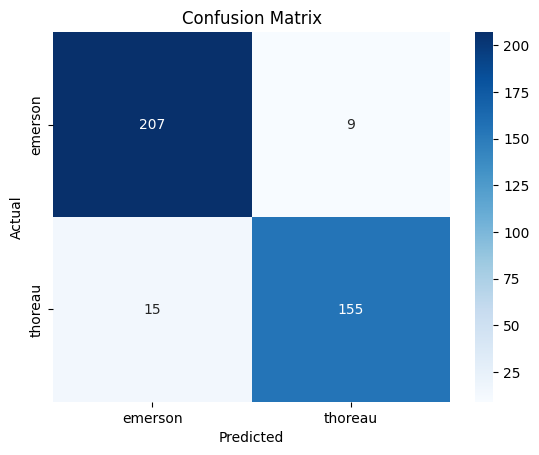

In [362]:
show_metrics(y_pred_trans, y_test_trans, "Fine-tuned DistilBERT")

## Let's check out the last 13 test samples that are misclassified.

In [363]:
def scalar_from_tensor(t):
  if t.dim() == 0:
    return t.item()
  elif t.dim() == 1:
    return t[0].item()
  else:
    raise ValueError(f"Unexpected tensor dimension: {t.dim()}")


In [364]:

y_test_trans = [scalar_from_tensor(t) for t in y_test_trans]
y_pred_trans = [scalar_from_tensor(t) for t in y_pred_trans]

print(f"y_test_trans: {y_test_trans[:5]}")
print(f"y_pred_trans: {y_pred_trans[:5]}")


y_test_trans: [1, 1, 0, 1, 0]
y_pred_trans: [1, 1, 0, 1, 0]


In [365]:
print("my_cat_labels")

rows = []
for i, (txt, lbl, pred) in enumerate(zip(x_test_trans, y_test_trans, y_pred_trans)):
  if lbl != pred:
    print(f"{lbl=},{pred=}")
    row =(my_cat_labels[lbl], my_cat_labels[pred], txt)
    print(f"{row=}")
    rows.append(row)

n_miss = len(rows)
print(f"Count of misclassified = {n_miss}")
misclassified_df = pd.DataFrame(rows, columns=["actual", "predicted", "text"])
misclassified_df.head(n_miss)


my_cat_labels
lbl=0,pred=1
row=('emerson', 'thoreau', 'The best of hospitality and of generosity is also not in the\n\nwill, but in fate. I find that I am not much to you; you do not need\n\nme; you do not feel me; then am I thrust out of doors, though you\n\nproffer me house and lands. No services are of any value, but only\n\nlikeness. When I have attempted to join myself to others by services,\n\nit proved an intellectual trick--no more.')
lbl=1,pred=0
row=('thoreau', 'emerson', 'The volatile truth of our words\n\nshould continually betray the inadequacy of the residual statement.\n\n Their truth is instantly _translated_; its literal monument alone\n\nremains. The words which express our faith and piety are not definite;\n\nyet they are significant and fragrant like frankincense to superior\n\nnatures.\n\n\n\n')
lbl=0,pred=1
row=('emerson', 'thoreau', 'What a disgrace it is to me to remember thy name! or to\n\nknow thy face to-morrow! or to take note how many pairs of silk\n\nstock

,actual,predicted,text
0,emerson,thoreau,The best of hospitality and of generosity is a...
1,thoreau,emerson,The volatile truth of our words\n\nshould cont...
2,emerson,thoreau,What a disgrace it is to me to remember thy na...
3,emerson,thoreau,They are not yet desired in\n\nthat way. We ha...
4,thoreau,emerson,I will breathe after my own fashion. Let us\n\...
5,emerson,thoreau,I can no longer live without elegance: but a c...
6,emerson,thoreau,"But the discomfort of unpunctuality, of confus..."
7,thoreau,emerson,A field of water betrays the spirit that is in...
8,emerson,thoreau,"This impoverishes the rich, suffering no grand..."
9,thoreau,emerson,"This alone wears well. For the most part, we a..."
